# TCGA `result` × GTEx τ


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

PROJ_ROOT = Path("/Users/neuropromotion/Desktop/miRNA/bulk_review")
PATH_TCGA = PROJ_ROOT / "pipeline_python" / "result_TCGA.csv"
PATH_GTEX_TAU = (
    PROJ_ROOT / "pipeline_python" / "tcga_gtex_shared_panel" / "tau_gtex.csv"
)
OUT_DIR = PROJ_ROOT / "pipeline_python" / "tcga_gtex_shared_panel"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in (PATH_TCGA, PATH_GTEX_TAU):
    if not p.is_file():
        raise FileNotFoundError(p)

In [83]:
tcga = pd.read_csv(PATH_TCGA)
if "mature_name" not in tcga.columns:
    raise ValueError("В result_TCGA ожидается mature_name")
tcga["mature_name"] = tcga["mature_name"].astype(str)
if "tcga_annotation" in tcga.columns:
    tcga = tcga.rename(columns={"tcga_annotation": "annotation_tcga"})

gtex = pd.read_csv(PATH_GTEX_TAU)
# tau_gtex.csv сейчас пишется с index=False — mature_name уже колонка.
# index_col=0 + присвоение из index давало и уровень индекса, и колонку mature_name → merge: ambiguous.
if gtex.columns[0].startswith("Unnamed") and "mature_name" in gtex.columns:
    gtex = gtex.drop(columns=[gtex.columns[0]])
if "mature_name" not in gtex.columns:
    raise ValueError("В tau_gtex.csv ожидается колонка mature_name")
gtex = gtex.reset_index(drop=True)
gtex["mature_name"] = gtex["mature_name"].astype(str)
if "annotation" in gtex.columns:
    gtex = gtex.rename(columns={"annotation": "annotation_gtex"})

merged = tcga.merge(gtex, on="mature_name", how="inner")
print("TCGA строк:", len(tcga), "| GTEx τ строк:", len(gtex), "| пересечение:", len(merged))
merged.head()


TCGA строк: 604 | GTEx τ строк: 516 | пересечение: 516


,mature_name,tcga_tau,annotation_tcga,n_projects_up,n_projects_down,median_log2fc,median_padj,binom_p_two_sided,binom_p_up,binom_p_down,STN_class,tcga_pref_type,tau_gtex,annotation_gtex,pref_smts_highq
0,hsa-let-7a-2-3p,0.357379,intermediate,3,1,-0.544267,9.617252e-04,0.625000,0.312500,0.937500,NOT_SIGNIFICANT,Histiocytoma,0.960525,specific,Bladder
1,hsa-let-7a-3p,0.231600,intermediate,1,0,-0.022187,2.011985e-05,1.000000,0.500000,1.000000,NOT_SIGNIFICANT,Renal cell carcinoma,0.770218,intermediate,Skin
2,hsa-let-7b-5p,0.153265,broad,2,2,-0.381554,8.303934e-07,1.000000,0.687500,0.687500,NOT_SIGNIFICANT,Cystadenocarcinoma,0.526175,intermediate,Breast
3,hsa-let-7c-3p,0.343961,intermediate,4,6,-0.454561,7.149929e-06,0.753906,0.828125,0.376953,NOT_SIGNIFICANT,Glioma,0.567580,intermediate,Cervix Uteri
4,hsa-let-7d-5p,0.288760,intermediate,0,0,0.294442,3.498912e-04,NaN,NaN,NaN,NOT_SIGNIFICANT,Renal cell carcinoma,0.687970,intermediate,Muscle


# FINAL CLASS

In [29]:
merged.loc[merged['tcga_tau'] < 0.8, 'tcga_pref_type'] = '-'
merged.loc[merged['tau_gtex'] < 0.8, 'pref_smts_highq'] = '-'
merged.head(10)

,mature_name,tcga_tau,annotation_tcga,n_projects_up,n_projects_down,median_log2fc,median_padj,binom_p_two_sided,binom_p_up,binom_p_down,STN_class,tcga_pref_type,tau_gtex,annotation_gtex,pref_smts_highq,final_annotation
0,hsa-let-7a-2-3p,0.357379,non-specific,3,1,-0.544267,9.617252e-04,0.625000,0.312500,0.937500,NOT_SIGNIFICANT,-,0.960525,specific,Bladder,GTEx-specific miR
1,hsa-let-7a-3p,0.231600,non-specific,1,0,-0.022187,2.011985e-05,1.000000,0.500000,1.000000,NOT_SIGNIFICANT,-,0.770218,non-specific,-,concordant non-specific miR
2,hsa-let-7b-5p,0.153265,non-specific,2,2,-0.381554,8.303934e-07,1.000000,0.687500,0.687500,NOT_SIGNIFICANT,-,0.526175,non-specific,-,concordant non-specific miR
3,hsa-let-7c-3p,0.343961,non-specific,4,6,-0.454561,7.149929e-06,0.753906,0.828125,0.376953,NOT_SIGNIFICANT,-,0.567580,non-specific,-,concordant non-specific miR
4,hsa-let-7d-5p,0.288760,non-specific,0,0,0.294442,3.498912e-04,NaN,NaN,NaN,NOT_SIGNIFICANT,-,0.687970,non-specific,-,concordant non-specific miR
5,hsa-let-7e-3p,0.390814,non-specific,1,6,-0.709104,1.494374e-08,0.125000,0.992188,0.062500,NOT_SIGNIFICANT,-,0.453570,non-specific,-,concordant non-specific miR
6,hsa-let-7e-5p,0.201121,non-specific,2,3,0.204418,4.216750e-05,1.000000,0.812500,0.500000,NOT_SIGNIFICANT,-,0.624621,non-specific,-,concordant non-specific miR
7,hsa-let-7g-3p,0.236778,non-specific,3,1,0.682538,1.251681e-09,0.625000,0.312500,0.937500,NOT_SIGNIFICANT,-,0.749971,non-specific,-,concordant non-specific miR
8,hsa-let-7g-5p,0.315751,non-specific,2,1,0.312695,7.824145e-05,1.000000,0.500000,0.875000,NOT_SIGNIFICANT,-,0.519805,non-specific,-,concordant non-specific miR
9,hsa-let-7i-5p,0.284522,non-specific,0,0,0.369536,3.092254e-08,NaN,NaN,NaN,NOT_SIGNIFICANT,-,0.585250,non-specific,-,concordant non-specific miR


In [225]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ---------- настройки ----------
FINAL_CHOICES = [
    'concordant specific miR',
    'TCGA-specific miR',
    'GTEx-specific miR',
    'concordant non-specific miR'
]

FINAL_COLORS = {
    'concordant specific miR': '#2ca02c',
    'TCGA-specific miR': '#d62728',
    'GTEx-specific miR': '#1f77b4',
    'concordant non-specific miR': '#7f7f7f'
}

STN_CLASS_COLORS = {
    "NOT_SIGNIFICANT": "gray",
    "UPREGULATED": "firebrick",
    "DOWNREGULATED": "navy",
}

# ---------- данные ----------
plot_df = merged.dropna(
    subset=["tcga_tau", "tau_gtex", "final_annotation"]
).copy().reset_index(drop=True)

# ---------- hover логика ----------
def _get_val(r, col, is_padj=False):
    v = r.get(col)
    if pd.isna(v): return "NA"
    if isinstance(v, float):
        return f"{v:.4e}" if is_padj else f"{v:.4f}"
    return str(v)

def _hover_text_row(r):
    # 1. Заголовок
    lines = [f"<b>{r['mature_name']}</b>", ""]
    
    # 2. Секция Specificity
    lines.append("<b>Specificity:</b>")
    ann_tcga = f" ({r['annotation_tcga']})" if pd.notna(r.get('annotation_tcga')) else ""
    lines.append(f"τ TCGA: {r['tcga_tau']:.4f}{ann_tcga}")
    
    ann_gtex = f" ({r['annotation_gtex']})" if pd.notna(r.get('annotation_gtex')) else ""
    lines.append(f"τ GTEx: {r['tau_gtex']:.4f}{ann_gtex}")
    
    lines.append(f"Cancer specificity (TCGA): {r.get('tcga_pref_type', 'NA')}")
    lines.append(f"Tissue specificity (GTEx): {r.get('pref_smts_highq', 'NA')}")
    
    # Делимитер между секциями
    lines.append("-----------------------")
    
    # 3. Секция DE cancer vs normal
    lines.append("<b>DE cancer vs normal:</b>")
    lines.append(f"n_projects_up: {r.get('n_projects_up', 'NA')}")
    lines.append(f"n_projects_down: {r.get('n_projects_down', 'NA')}")
    lines.append(f"median_log2FC: {_get_val(r, 'median_log2fc')}")
    lines.append(f"median padj: {_get_val(r, 'median_padj', True)}")
    
    # Binomial test (STN_class) жирным
    stn_val = r.get('STN_class', 'NA')
    lines.append(f"Binomial test: <b>{stn_val}</b>")

    return "<br>".join(lines)

hover_text = [_hover_text_row(plot_df.loc[i]) for i in range(len(plot_df))]

# ---------- категории ----------
fa_seen = plot_df["final_annotation"].astype(str)
fa_categories = [c for c in FINAL_CHOICES if (fa_seen == c).any()]
for c in sorted(fa_seen.unique()):
    if c not in fa_categories: fa_categories.append(c)

fc_seen = plot_df["STN_class"].astype(str)
_fc_pref = ["NOT_SIGNIFICANT", "UPREGULATED", "DOWNREGULATED"]
fc_categories = [c for c in _fc_pref if (fc_seen == c).any()]
for c in sorted(fc_seen.unique()):
    if c not in fc_categories: fc_categories.append(c)

# ---------- plot ----------
mk = dict(size=14, opacity=0.85, line=dict(width=0.6, color="white"))
traces = []

for cat in fa_categories:
    sub = plot_df[fa_seen == cat]
    traces.append(go.Scatter(
        x=sub["tau_gtex"], y=sub["tcga_tau"],
        mode="markers", name=cat, visible=True,
        marker={**mk, "color": FINAL_COLORS.get(cat, "#888888")},
        text=[hover_text[i] for i in sub.index],
        hoverinfo="text"
    ))

for cat in fc_categories:
    sub = plot_df[fc_seen == cat]
    traces.append(go.Scatter(
        x=sub["tau_gtex"], y=sub["tcga_tau"],
        mode="markers", name=cat, visible=False,
        marker={**mk, "color": STN_CLASS_COLORS.get(cat, "#888888")},
        text=[hover_text[i] for i in sub.index],
        hoverinfo="text"
    ))

# ---------- figure ----------
fig = go.Figure(data=traces)

# Диагональ
fig.add_shape(
    type="line", x0=0, y0=0, x1=1, y1=1,
    line=dict(color="rgba(0,0,0,0.4)", dash="dash")
)

# Настройка осей - убираем лишние 1.05, ставим строго 1
fig.update_xaxes(
    range=[0, 1.05], 
    title="τ GTEx", 
    autorange=False,
    constrain="domain",
    tickmode='array',
    tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

fig.update_yaxes(
    range=[0, 1.05], 
    title="τ TCGA", 
    scaleanchor="x", 
    scaleratio=1,
    autorange=False,
    constrain="domain",
    tickmode='array',
    tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

# Настройка видимости для кнопок
n_fa, n_fc = len(fa_categories), len(fc_categories)
vis_fa = [True] * n_fa + [False] * n_fc
vis_fc = [False] * n_fa + [True] * n_fc

fig.update_layout(
    title="TCGA vs GTEx τ",
    template="plotly_white",
    
    # КЛЮЧЕВОЕ ИЗМЕНЕНИЕ: 
    # Задаем фиксированную высоту (например, 850px), 
    # чтобы график был крупным. Ширина подстроится сама.
    height=850, 
    autosize=True,

    # l=70 (подпись оси Y), r=250 (место под легенду), t=120 (заголовок/кнопки), b=70 (ось X)
    margin=dict(l=70, r=250, t=120, b=70), 
    
    legend=dict(
        orientation="v",
        x=1.02, # Легенда сразу за краем графика
        y=1,
        xanchor="left",
        yanchor="top",
        bordercolor="LightGrey",
        borderwidth=1
    ),
    
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0,
            y=1.08, # Чуть ниже, чтобы не было гигантского разрыва сверху
            xanchor="left",
            yanchor="bottom",
            buttons=[
                dict(label="Annotation", method="update", args=[{"visible": vis_fa}]),
                dict(label="Binomial Test", method="update", args=[{"visible": vis_fc}]),
            ]
        )
    ]
)

# ---------- сохранить и показать ----------
_html = OUT_DIR / "tau_scatter_final_clean.html"
fig.write_html(_html, include_plotlyjs="cdn")
fig.show()

In [4]:
merged[merged["STN_class"] == "UPREGULATED"].head()

,mature_name,tcga_tau,annotation_tcga,n_projects_up,n_projects_down,median_log2fc,median_padj,binom_p_two_sided,binom_p_up,binom_p_down,STN_class,tcga_pref_type,tau_gtex,annotation_gtex,pref_smts_highq
17,hsa-miR-105-5p,0.766220,intermediate,12,1,5.652880,1.978612e-12,0.003418,0.001709,0.999878,UPREGULATED,Germ cell tumor,0.972350,specific,Brain
43,hsa-miR-1269a,0.744244,intermediate,13,1,4.397855,2.299072e-17,0.001831,0.000916,0.999939,UPREGULATED,Carcinosarcoma,0.940851,specific,Kidney
63,hsa-miR-1301-3p,0.340868,intermediate,11,1,1.448722,1.940518e-09,0.006348,0.003174,0.999756,UPREGULATED,Renal cell carcinoma,0.813158,specific,Brain
65,hsa-miR-1307-5p,0.157360,broad,9,0,1.511624,3.180029e-22,0.003906,0.001953,1.000000,UPREGULATED,Pheochromocytoma,0.645721,intermediate,Pituitary
68,hsa-miR-130b-3p,0.328094,intermediate,12,0,1.506678,1.954801e-15,0.000488,0.000244,1.000000,UPREGULATED,Nephroblastoma,0.708859,intermediate,Pancreas


In [5]:
merged[merged["STN_class"] == "DOWNREGULATED"].head()

,mature_name,tcga_tau,annotation_tcga,n_projects_up,n_projects_down,median_log2fc,median_padj,binom_p_two_sided,binom_p_up,binom_p_down,STN_class,tcga_pref_type,tau_gtex,annotation_gtex,pref_smts_highq
73,hsa-miR-133b,0.853749,specific,3,14,-2.212578,2.248655e-13,0.012726,0.998825,0.006363,DOWNREGULATED,Leiomyosarcoma,0.990722,specific,Muscle
85,hsa-miR-139-3p,0.398484,intermediate,1,16,-2.501329,2.356733e-24,0.000275,0.999992,0.000137,DOWNREGULATED,Neuroendocrine carcinoma,0.845641,specific,Brain
86,hsa-miR-140-3p,0.166078,broad,0,8,-1.181627,7.313206e-22,0.007812,1.000000,0.003906,DOWNREGULATED,Renal cell carcinoma,0.875632,specific,Blood Vessel
91,hsa-miR-143-3p,0.228353,intermediate,2,13,-1.385788,5.338020e-16,0.007385,0.999512,0.003693,DOWNREGULATED,Leiomyosarcoma,0.792749,intermediate,Bladder
95,hsa-miR-145-3p,0.478543,intermediate,1,14,-1.596556,7.283341e-19,0.000977,0.999969,0.000488,DOWNREGULATED,Renal cell carcinoma,0.724808,intermediate,Blood Vessel


In [76]:
FINAL_CHOICES = [
    'concordant specific miR',
    'TCGA-specific miR',
    'GTEx-specific miR',
    'concordant non-specific miR'
]

FINAL_COLORS = {
    'GTEx-specific miR': '#B8860B',
    'concordant specific miR': '#2ca02c',
    'concordant non-specific miR': '#7f7f7f',
    'TCGA-specific miR': '#9467bd'
}

def plot_tau_scatter(
    df,
    title_suffix="",
    pdf_path=None,
    point_size=100,
    alpha=0.8,
):

    plot_df = df.dropna(
        subset=["tau_gtex", "tcga_tau", "final_annotation"]
    ).copy()

    rho, p = spearmanr(
        plot_df["tau_gtex"],
        plot_df["tcga_tau"]
    )

    fig, ax = plt.subplots(
        figsize=(8.2, 7.4),
        dpi=300
    )

    fig.patch.set_facecolor("white")

    # используем фиксированный порядок
    categories = [
        c for c in FINAL_CHOICES
        if c in plot_df["final_annotation"].values
    ]

    for cat in categories:
        sub = plot_df[
            plot_df["final_annotation"] == cat
        ]

        ax.scatter(
            sub["tau_gtex"],
            sub["tcga_tau"],
            s=point_size,
            alpha=alpha,
            c=[FINAL_COLORS.get(cat, "gray")],
            edgecolors="white",
            linewidths=0.4,
            label=f"{cat} (n={len(sub)})"
        )

    # diagonal
    ax.plot(
        [0, 1], [0, 1],
        ls="--",
        lw=1,
        alpha=0.5
    )

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

    ax.set_xlabel("τ GTEx", fontsize=20)
    ax.set_ylabel("τ TCGA", fontsize=20)

    ax.set_title(
        f"TCGA vs GTEx τ\n"
        f"Spearman ρ={rho:.3f}, p={p:.1e}"
        + (f"\n{title_suffix}" if title_suffix else ""),
        fontsize=13
    )

    ax.set_aspect("equal")

    ax.legend(
        bbox_to_anchor=(1.03, 1),
        loc="upper left",
        frameon=False,
        fontsize=9,
        title="final_annotation"
    )

    plt.tight_layout()

    if pdf_path:
        plt.savefig(
            pdf_path,
            bbox_inches="tight",
            format="pdf"
        )

    plt.show()

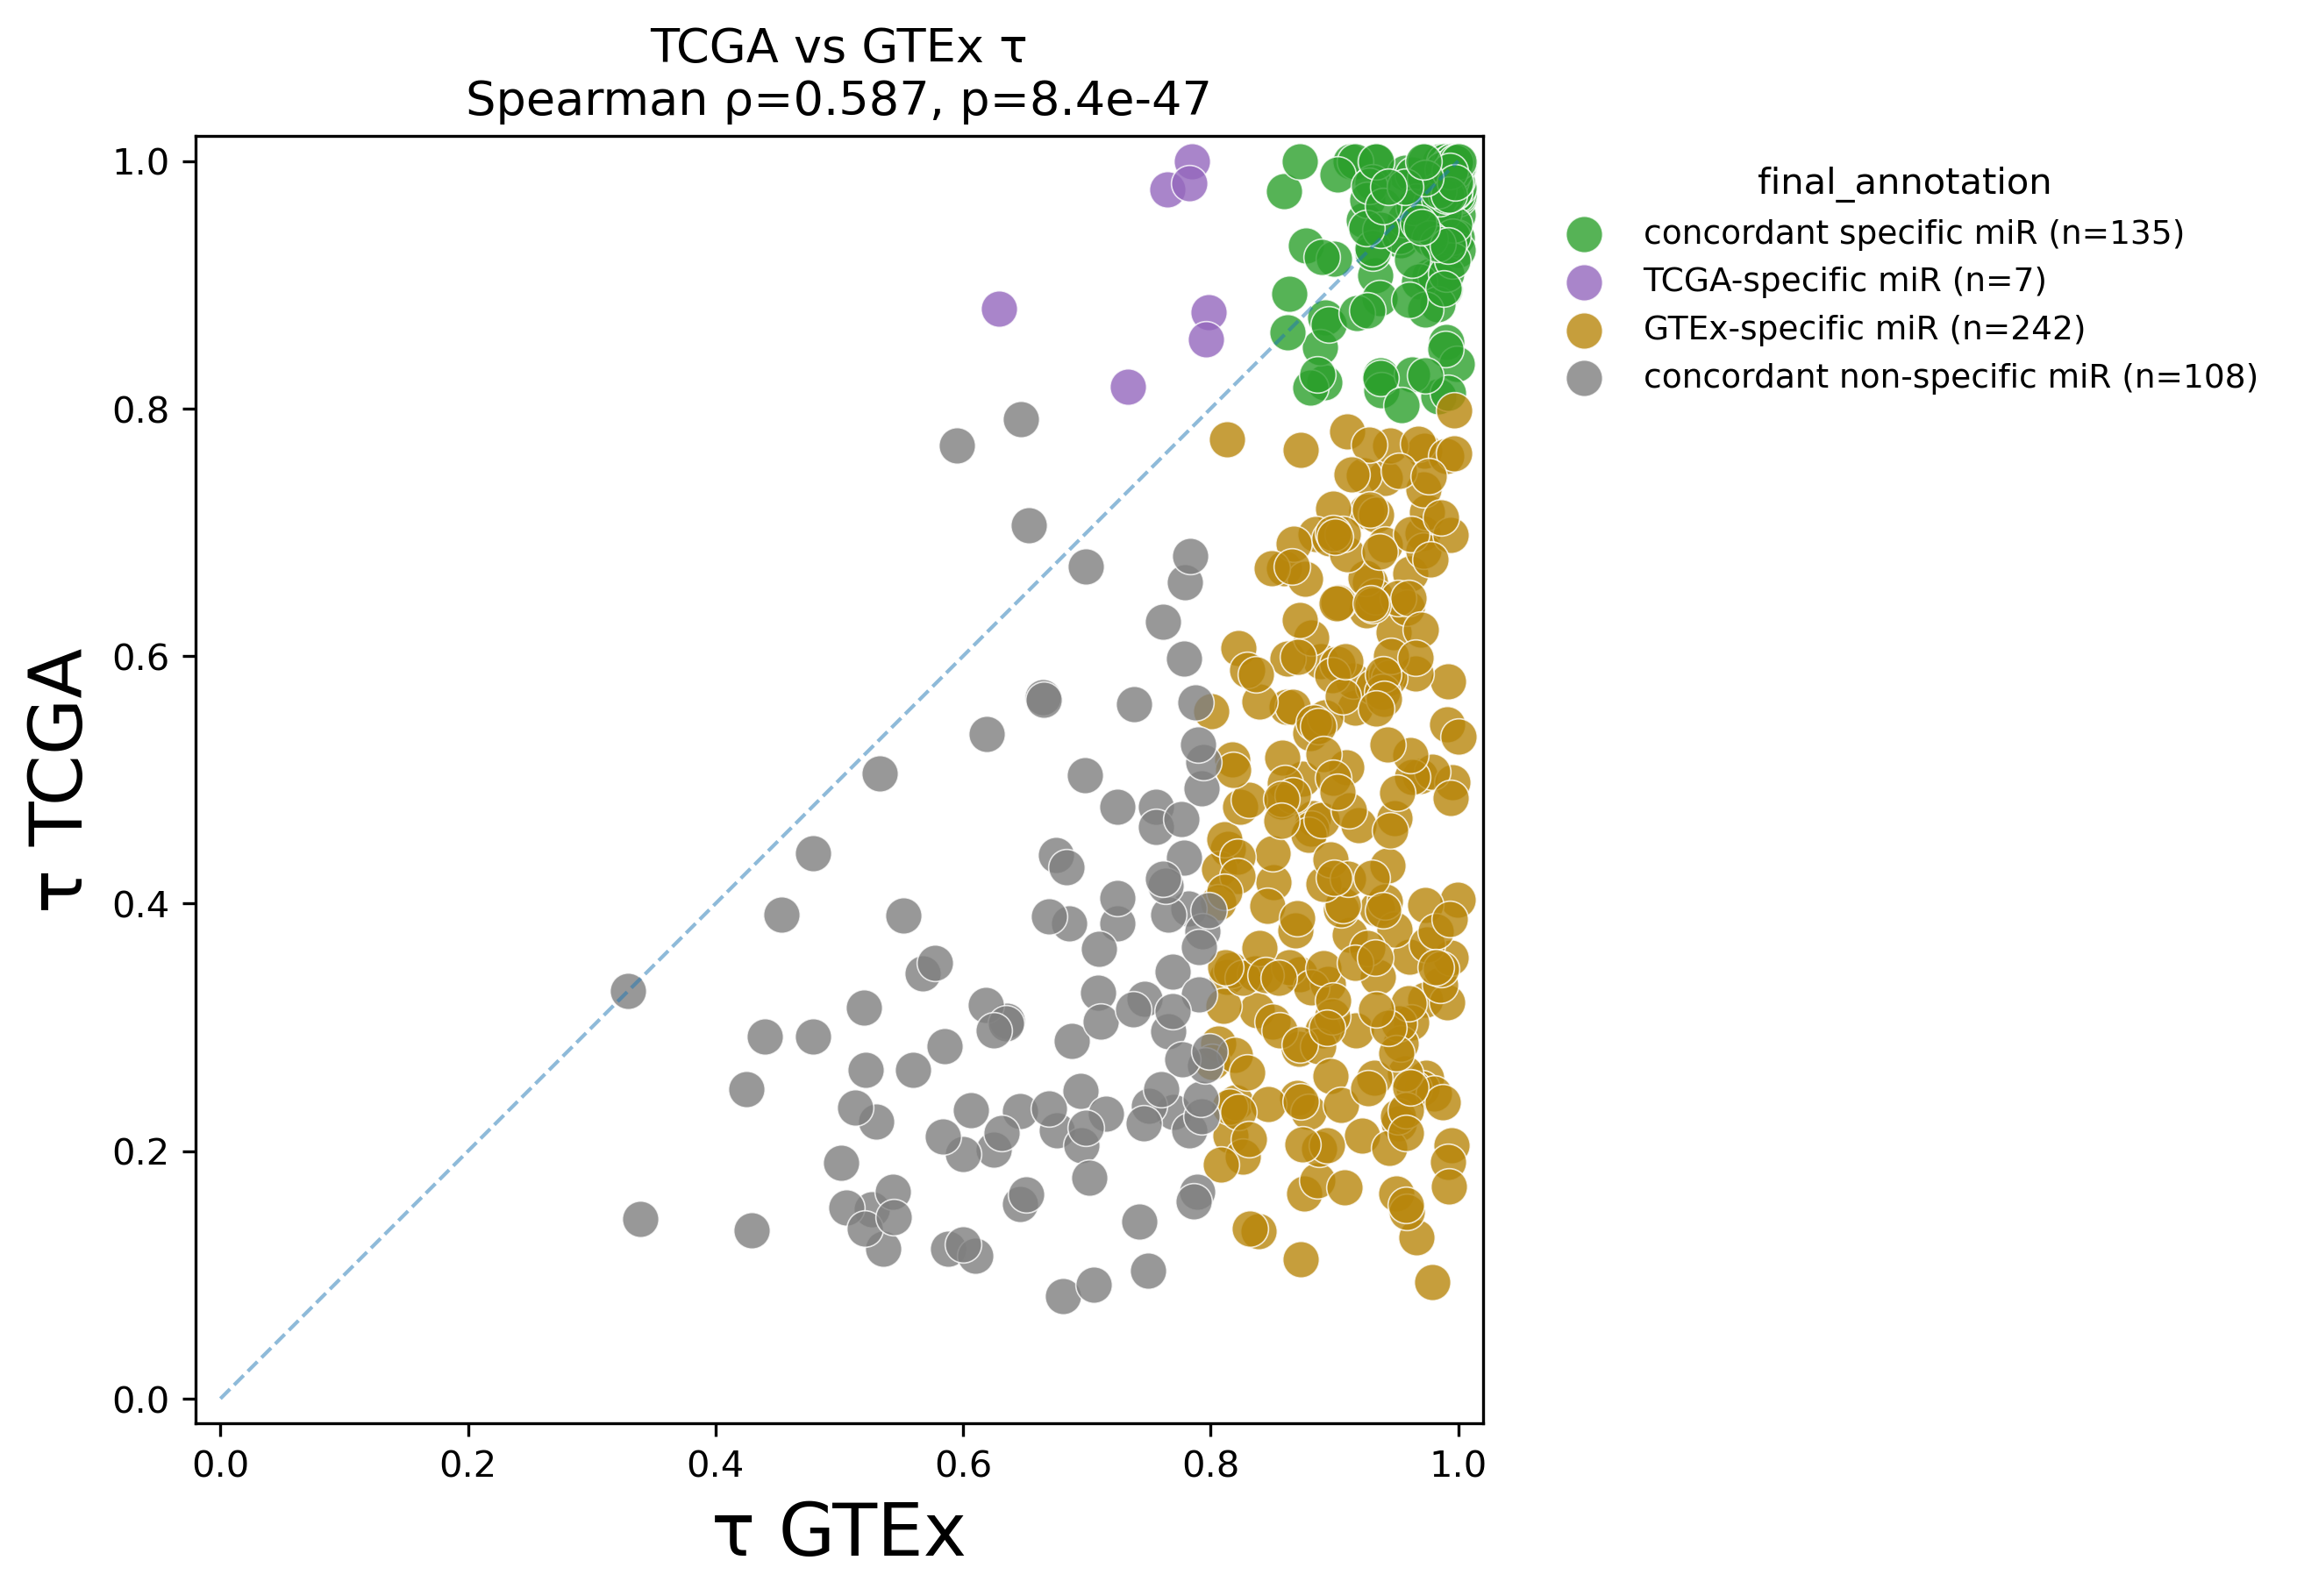

In [77]:
plot_tau_scatter(
    merged,
    pdf_path="/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/tau_vs_gtex_STN.pdf"
)

In [14]:
import pandas as pd
import numpy as np

conditions = [
    merged['tcga_tau'] < 0.8,
    merged['tcga_tau'] >= 0.8
]


choices = ['non-specific', 'specific']

merged['annotation_tcga'] = np.select(
    conditions,
    choices,
    default=pd.NA
)

conditions = [
    merged['tau_gtex'] < 0.8,
    merged['tau_gtex'] >= 0.8
]


choices = ['non-specific', 'specific']

merged['annotation_gtex'] = np.select(
    conditions,
    choices,
    default=pd.NA
)

In [15]:
import pandas as pd
import numpy as np

conditions = [
    (merged['annotation_tcga'] == 'specific') & (merged['annotation_gtex'] == 'specific'),
    (merged['annotation_tcga'] == 'specific') & (merged['annotation_gtex'] == 'non-specific'),
    (merged['annotation_tcga'] == 'non-specific') & (merged['annotation_gtex'] == 'specific'),
    (merged['annotation_tcga'] == 'non-specific') & (merged['annotation_gtex'] == 'non-specific')
]

choices = [
    'concordant specific miR',
    'TCGA-specific miR',
    'GTEx-specific miR',
    'concordant non-specific miR'
]
merged['final_annotation'] = np.select(
    conditions,
    choices,
    default=pd.NA
)

In [3]:
import pandas as pd
#merged.to_csv('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/result_merged.csv', index=False)
merged = pd.read_csv('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/result_merged.csv')

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tau_filled_distributions(
    df,
    save_pdf=None
):
    # Очистка данных
    d = df.dropna(
        subset=["tau_gtex", "tcga_tau"]
    ).copy()

    # Расчет медиан
    median_gtex = d["tau_gtex"].median()
    median_tcga = d["tcga_tau"].median()

    ########################################
    # figure
    ########################################
    fig, ax = plt.subplots(
        figsize=(8, 5),
        dpi=300
    )

    ########################################
    # GTEx KDE (filled)
    ########################################
    sns.kdeplot(
        d["tau_gtex"],
        fill=True,
        color="steelblue",
        alpha=0.45,
        linewidth=2,
        label=f"GTEx (median: {median_gtex:.2f})",
        ax=ax
    )
    # Вертикальная линия медианы для GTEx
    ax.axvline(
        median_gtex, 
        color="steelblue", 
        linestyle="--", 
        linewidth=1.5, 
        alpha=0.8
    )

    ########################################
    # TCGA KDE (filled)
    ########################################
    sns.kdeplot(
        d["tcga_tau"],
        fill=True,
        color="firebrick",
        alpha=0.40,
        linewidth=2,
        label=f"TCGA (median: {median_tcga:.2f})",
        ax=ax
    )
    # Вертикальная линия медианы для TCGA
    ax.axvline(
        median_tcga, 
        color="firebrick", 
        linestyle="--", 
        linewidth=1.5, 
        alpha=0.8
    )

    ########################################
    # cosmetics
    ########################################
    ax.set_xlim(0, 1)

    ax.set_xlabel("τ (specificity)", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)

    ax.set_title(
        "miRNA specificity distribution: tissue vs cancer",
        fontsize=13,
        fontweight="bold"
    )

    # Размещаем легенду так, чтобы она не перекрывала график
    ax.legend(frameon=False, loc='upper left')

    sns.despine()
    plt.tight_layout()

    if save_pdf:
        plt.savefig(save_pdf, bbox_inches="tight")

    plt.show()

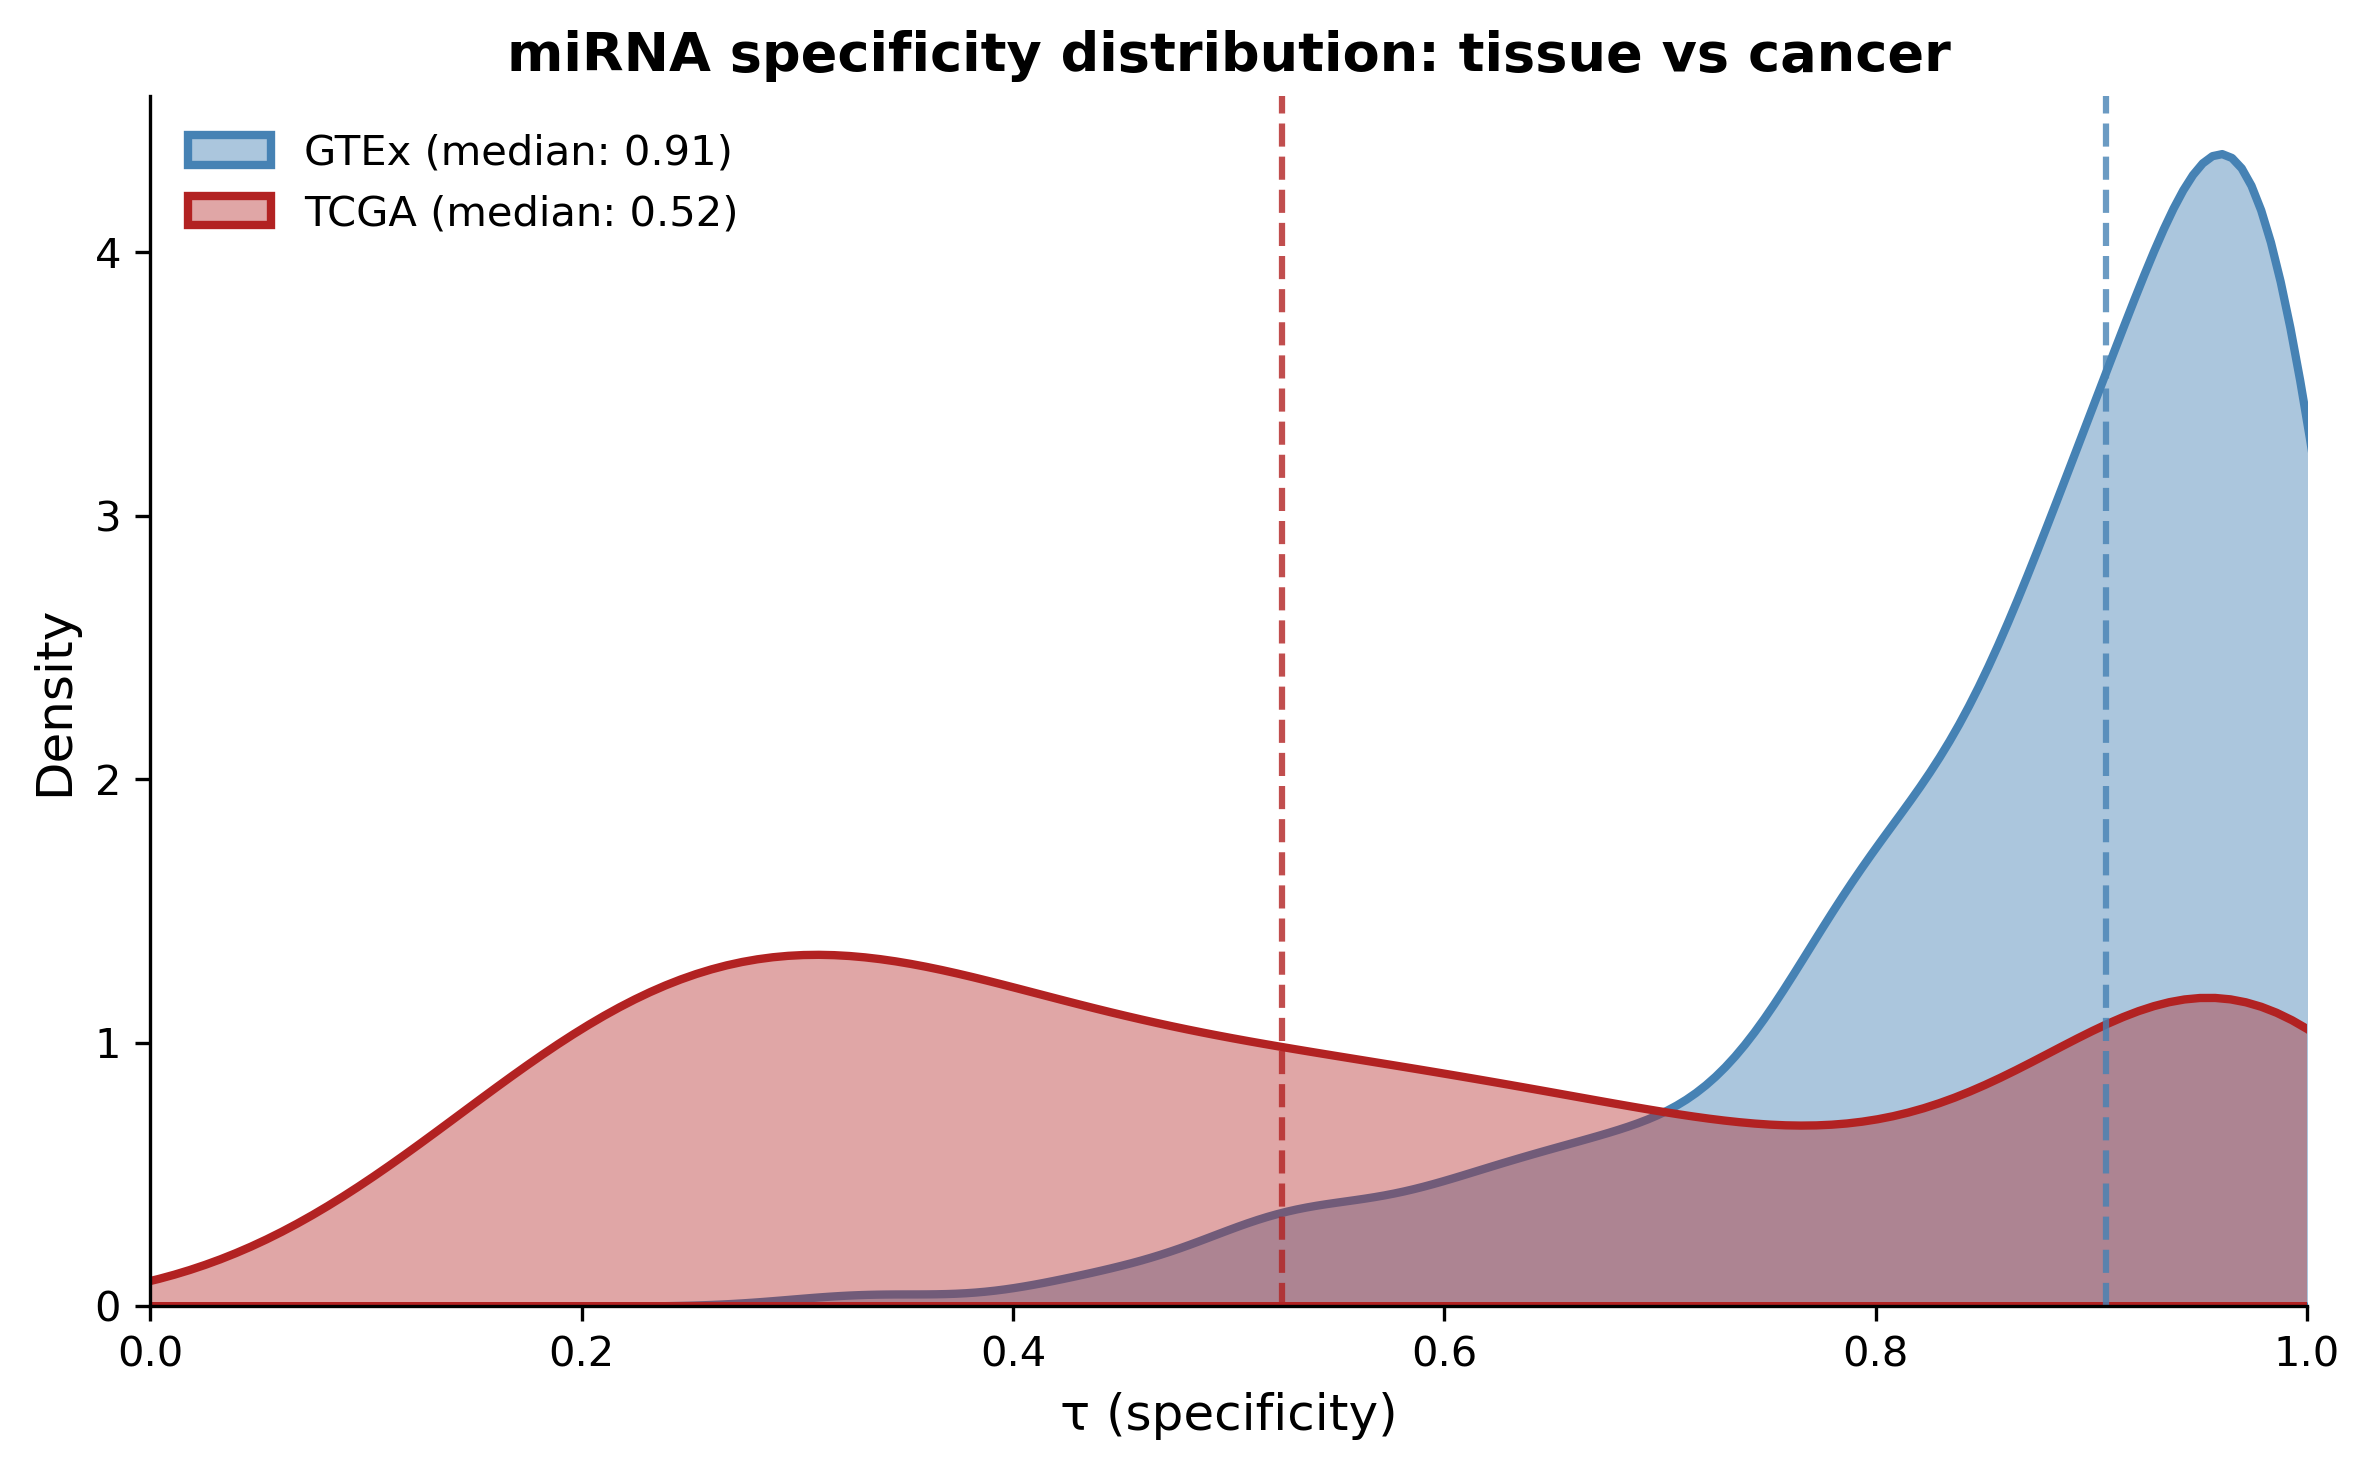

In [63]:
plot_tau_filled_distributions(
    merged,
    save_pdf = '/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/tau_distributions.pdf'
)

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_tau_distributions_separately(
    df,
    save_pdf_prefix=None
):

    d = df.dropna(
        subset=["tau_gtex", "tcga_tau"]
    ).copy()

    ########################################
    # GTEx
    ########################################

    fig1, ax1 = plt.subplots(figsize=(8, 5), dpi=300)

    sns.kdeplot(
        d["tau_gtex"],
        fill=True,
        color="steelblue",
        alpha=0.5,
        linewidth=2,
        ax=ax1
    )

    ax1.set_xlim(0, 1)
    ax1.set_xlabel("τ (GTEx tissue specificity)", fontsize=12)
    ax1.set_ylabel("Density", fontsize=12)
    #ax1.set_title("GTEx: distribution of miRNA tissue specificity", fontsize=13, fontweight="bold")
    ax1.grid(False)
    sns.despine()
    plt.tight_layout()

    if save_pdf_prefix:
        plt.savefig(f"{save_pdf_prefix}_GTEx.pdf", bbox_inches="tight")

    plt.show()

    ########################################
    # TCGA
    ########################################

    fig2, ax2 = plt.subplots(figsize=(8, 5), dpi=300)

    sns.kdeplot(
        d["tcga_tau"],
        fill=True,
        color="firebrick",
        alpha=0.5,
        linewidth=2,
        ax=ax2
    )

    ax2.set_xlim(0, 1)
    ax2.set_xlabel("τ (TCGA cancer specificity)", fontsize=12)
    ax2.set_ylabel("Density", fontsize=12)
    #ax2.set_title("TCGA: distribution of miRNA cancer specificity", fontsize=13, fontweight="bold")
    ax2.grid(False)
    sns.despine()
    plt.tight_layout()

    if save_pdf_prefix:
        plt.savefig(f"{save_pdf_prefix}_TCGA.pdf", bbox_inches="tight")

    plt.show()

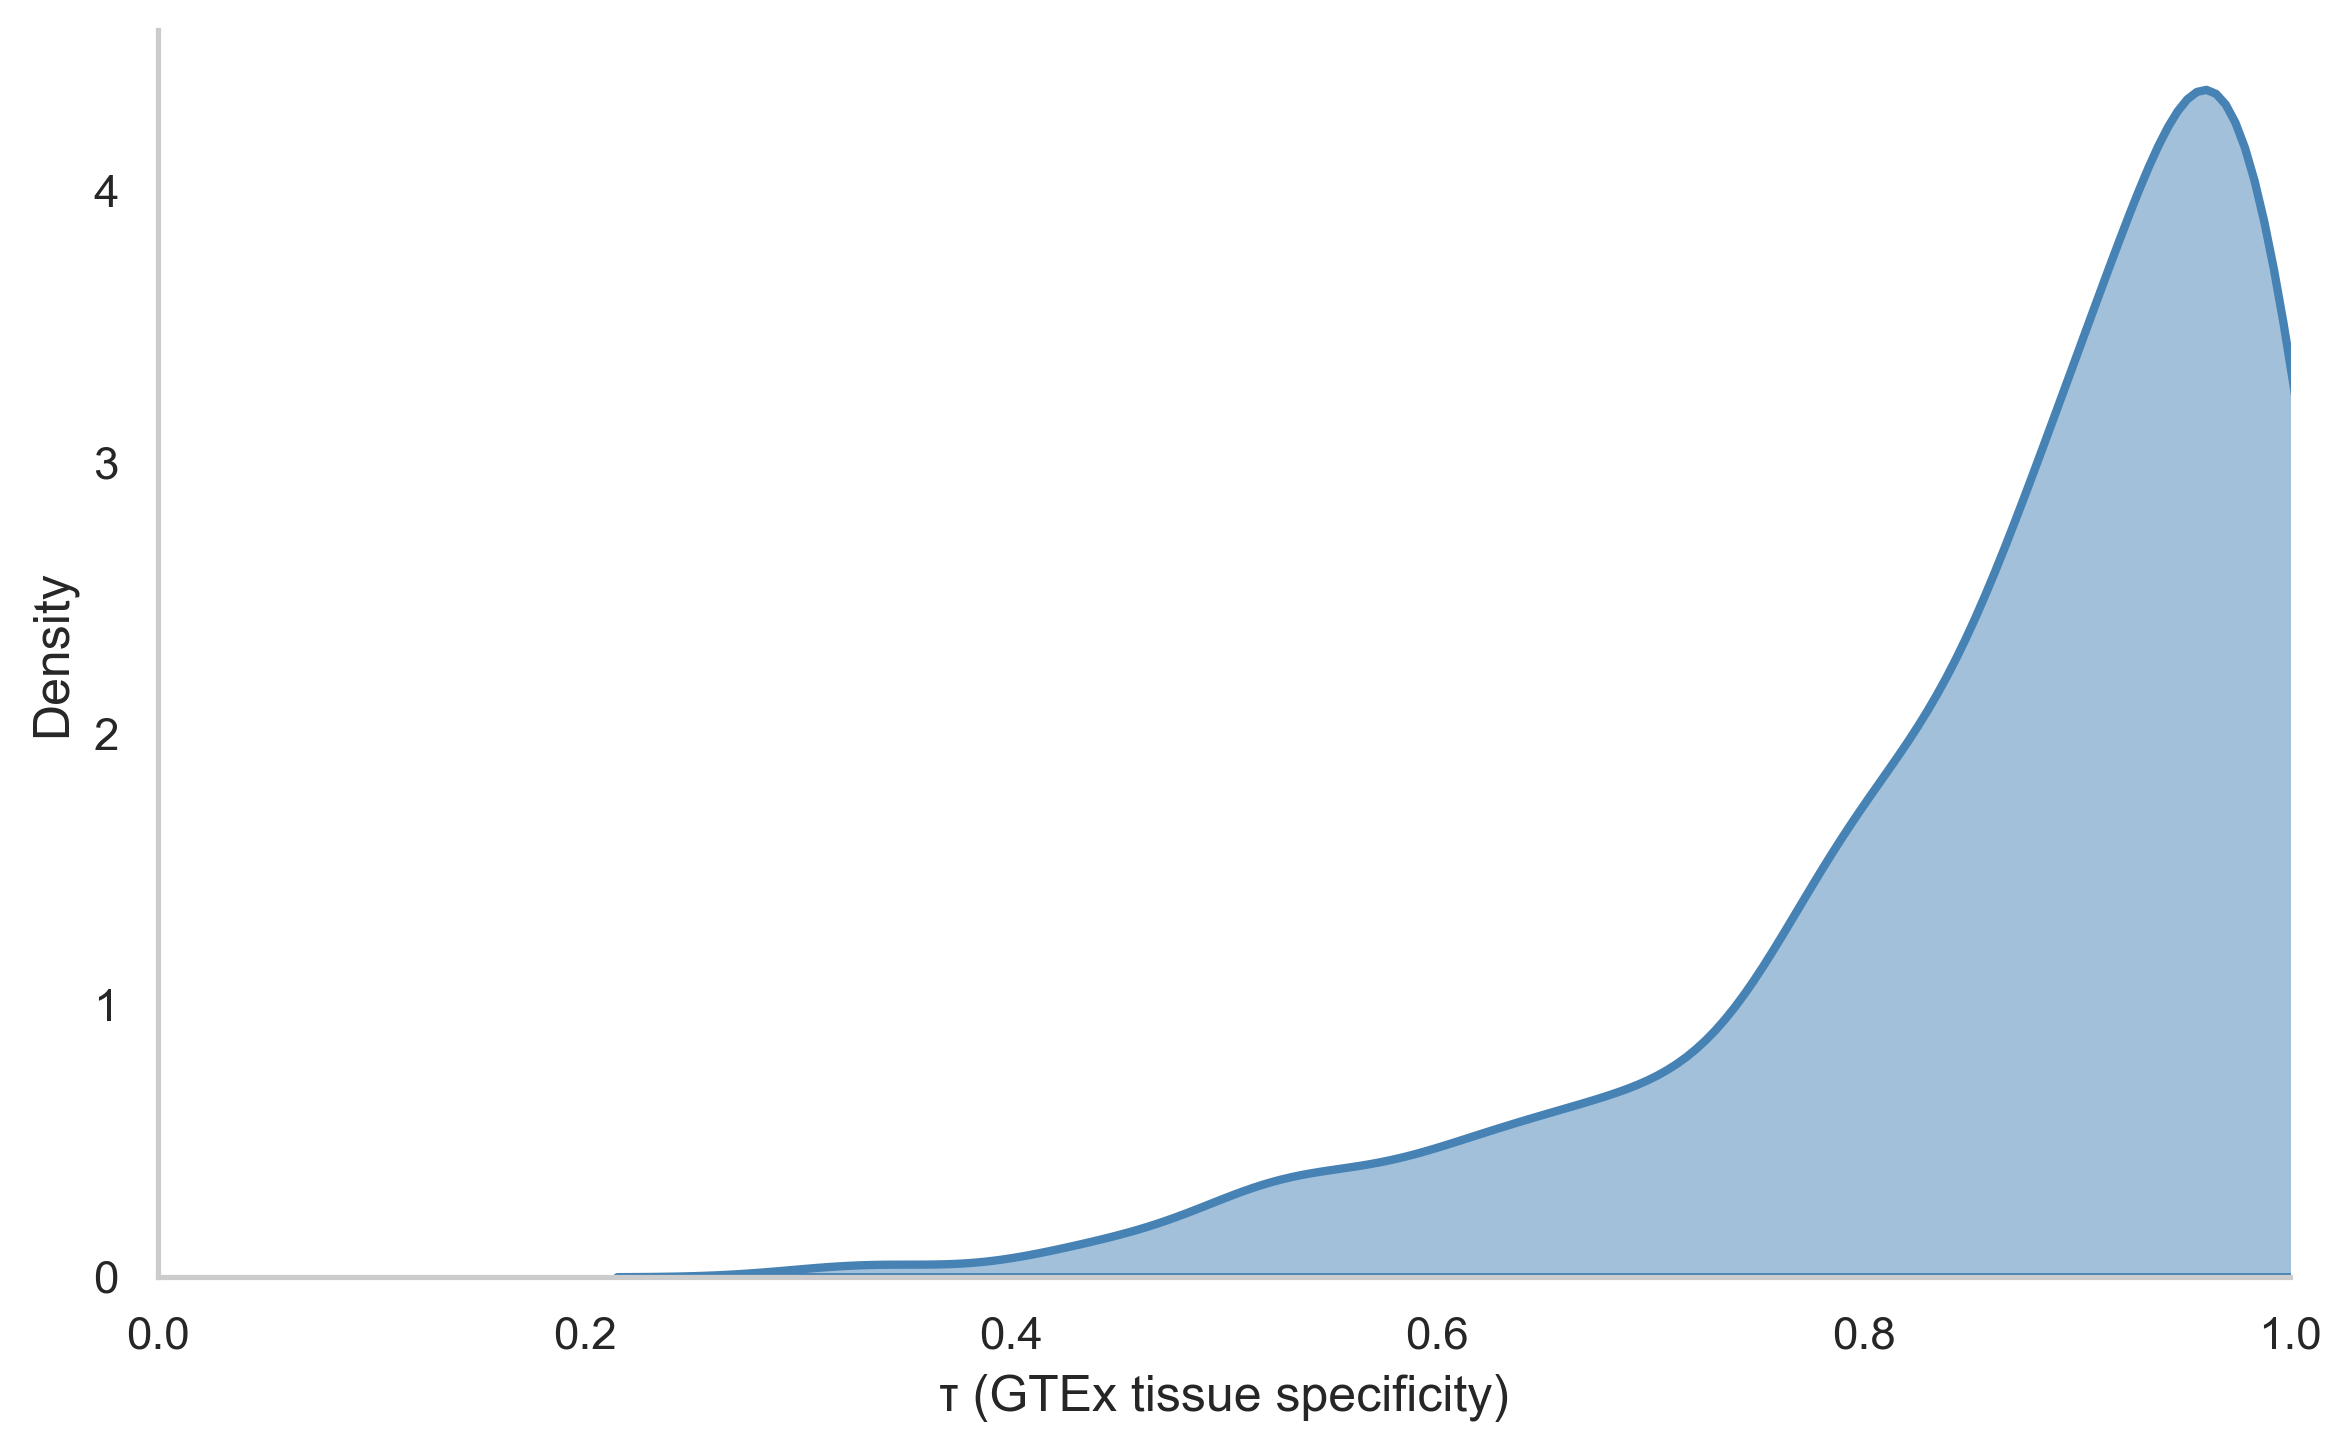

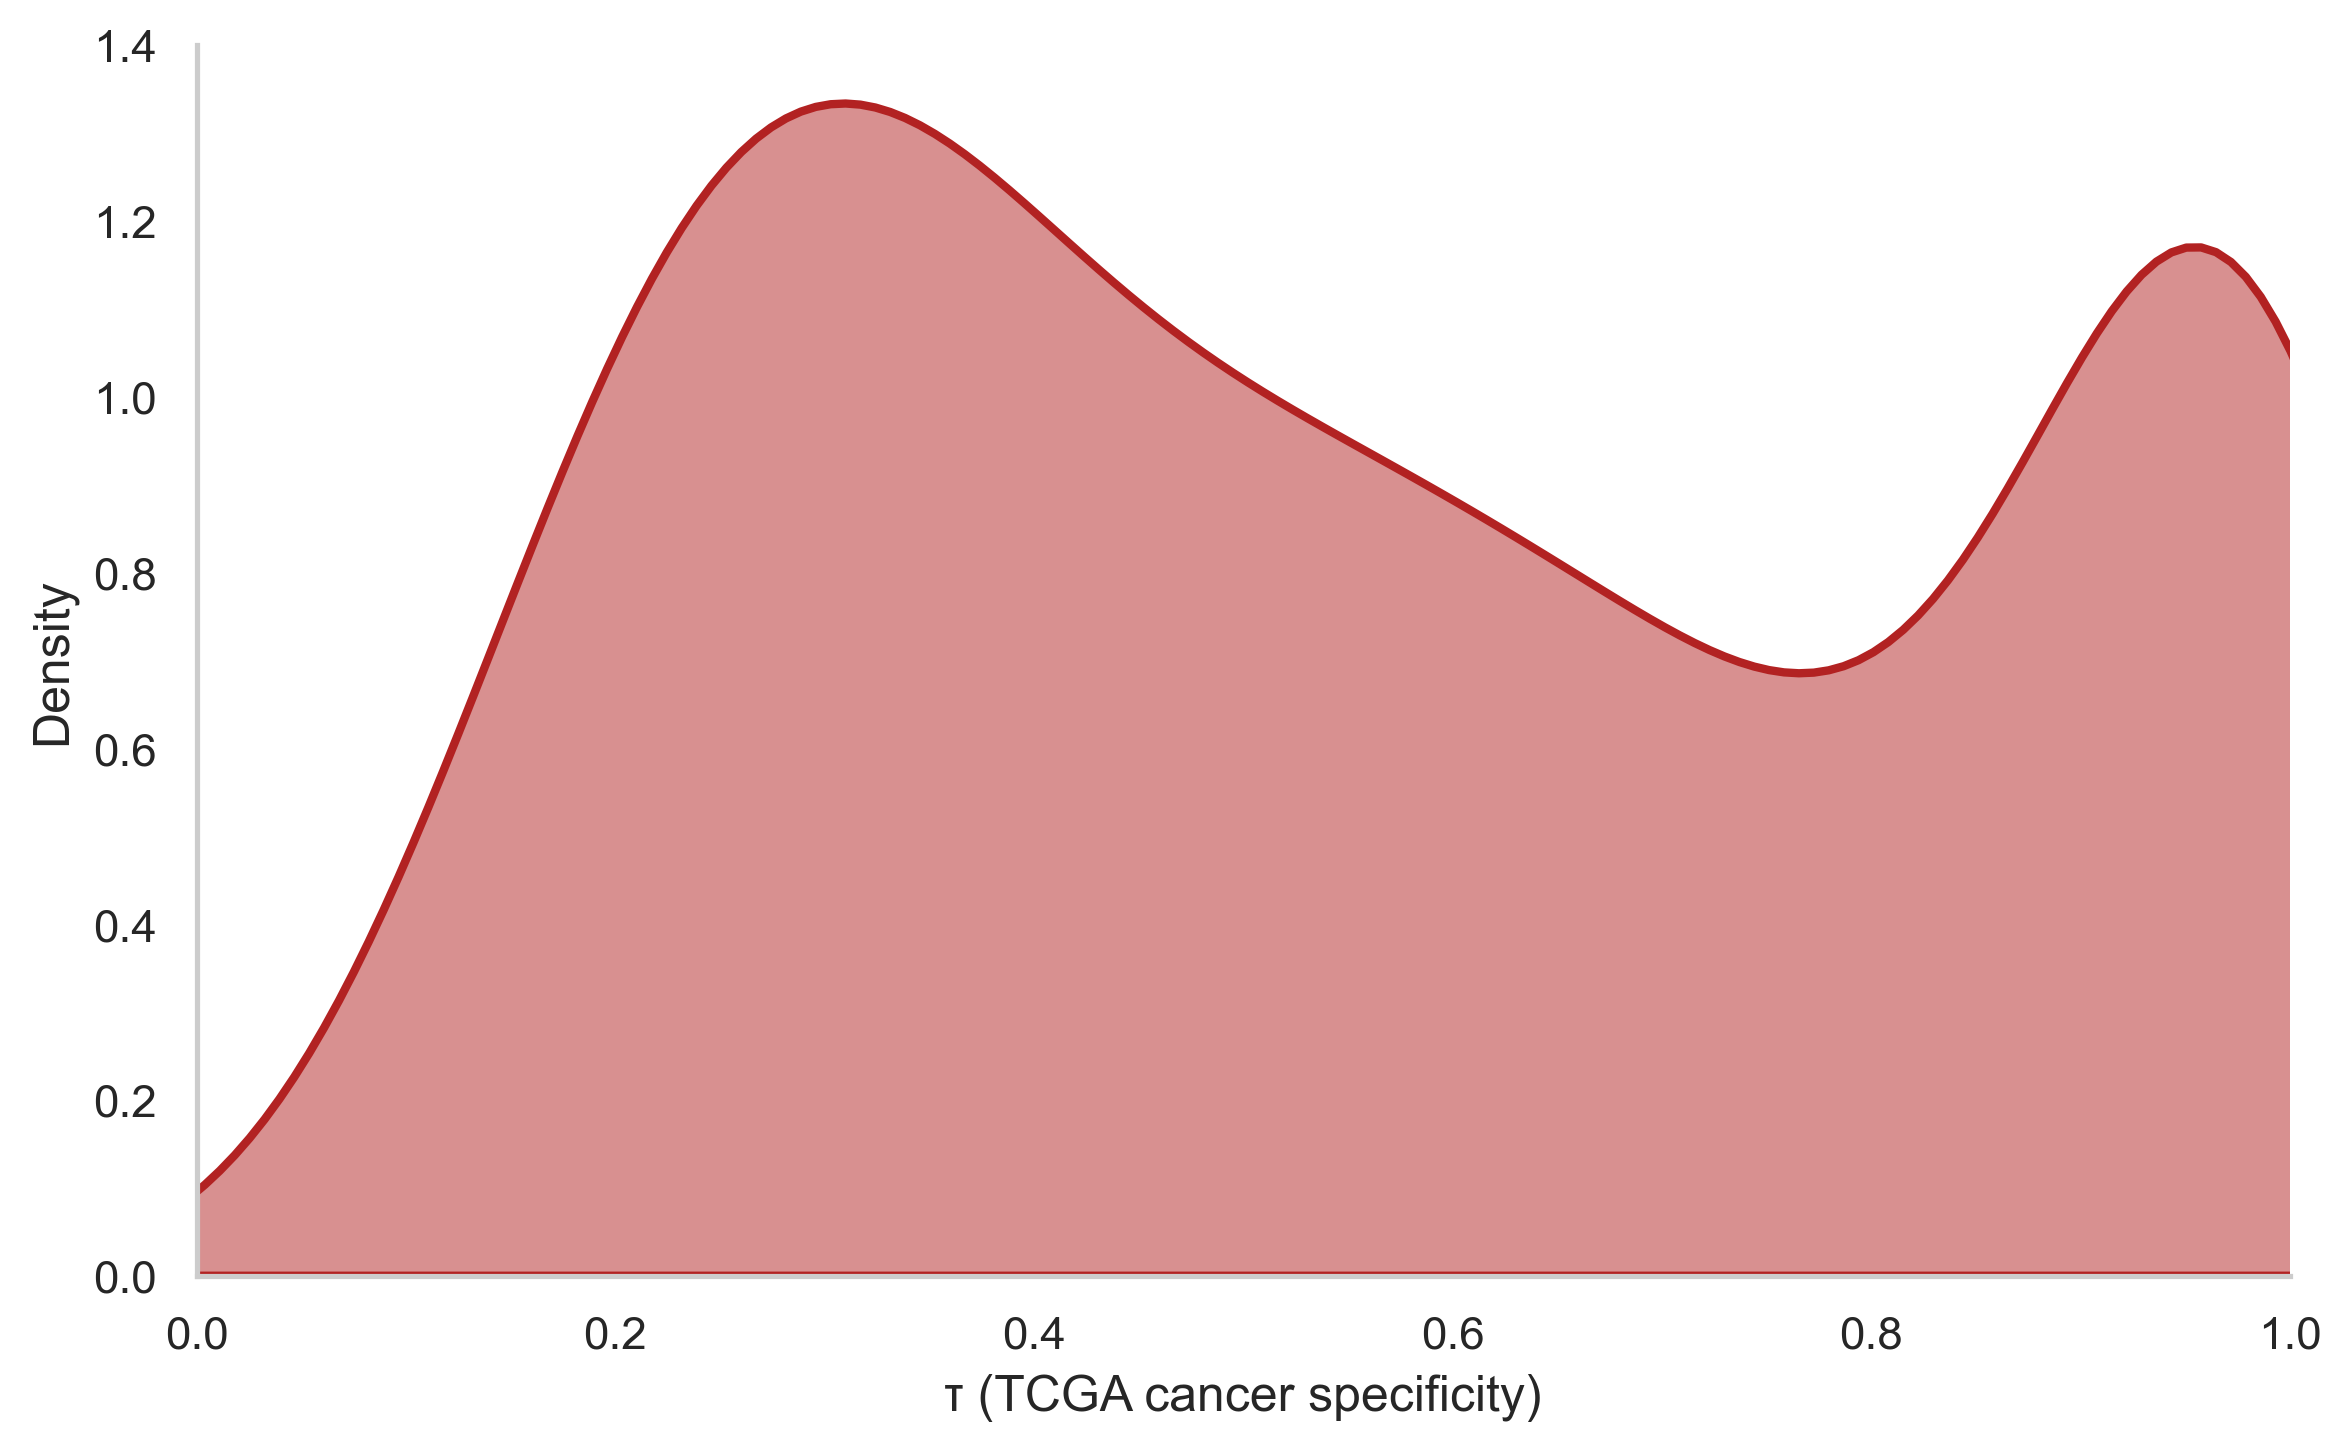

In [183]:
plot_tau_distributions_separately(
    merged,
    save_pdf_prefix="/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/tau_distribution"
)

In [ ]:
h_up =merged[merged['binom_p_up'] < 0.01][merged[merged['binom_p_up'] < 0.01]['median_log2fc'] > 1].reset_index(drop=True)
h_down = merged[merged['binom_p_down'] < 0.01][merged[merged['binom_p_down'] < 0.01]['median_log2fc'] < -1].reset_index(drop=True)

In [107]:
cols = ['mature_name', 'tcga_tau', 'tau_gtex', 'tcga_pref_type', 'pref_smts_highq',  
'n_projects_up', 'n_projects_down', 'binom_p_two_sided', 'binom_p_up', 'binom_p_down', 'STN_class', 'median_log2fc', 'median_padj', 'final_annotation']

h_up[cols].head(2)

,mature_name,tcga_tau,tau_gtex,tcga_pref_type,pref_smts_highq,n_projects_up,n_projects_down,binom_p_two_sided,binom_p_up,binom_p_down,STN_class,median_log2fc,median_padj,final_annotation
0,hsa-miR-105-5p,0.766220,0.972350,-,Brain,12,1,0.003418,0.001709,0.999878,UPREGULATED,5.652880,1.978612e-12,GTEx-specific miR
1,hsa-miR-1269a,0.744244,0.940851,-,Kidney,13,1,0.001831,0.000916,0.999939,UPREGULATED,4.397855,2.299072e-17,GTEx-specific miR


In [108]:
h_down[cols].head(2)

,mature_name,tcga_tau,tau_gtex,tcga_pref_type,pref_smts_highq,n_projects_up,n_projects_down,binom_p_two_sided,binom_p_up,binom_p_down,STN_class,median_log2fc,median_padj,final_annotation
0,hsa-miR-133b,0.853749,0.990722,Leiomyosarcoma,Muscle,3,14,0.012726,0.998825,0.006363,DOWNREGULATED,-2.212578,2.248655e-13,concordant specific miR
1,hsa-miR-139-3p,0.398484,0.845641,-,Brain,1,16,0.000275,0.999992,0.000137,DOWNREGULATED,-2.501329,2.356733e-24,GTEx-specific miR


In [109]:
selected_mirs = pd.concat([h_up[cols], h_down[cols]], axis=0)
selected_mirs.rename(columns={'tcga_tau': 'τ TCGA', 'tau_gtex': 'τ GTEx', 
'tcga_pref_type': 'TCGA specificity', 'pref_smts_highq': 'GTEx specificity', 
'final_annotation': 'specificity class', 'STN_class': 'binomial class', 'mature_name' :'miRNA'}, inplace=True)
selected_mirs.head()

,miRNA,τ TCGA,τ GTEx,TCGA specificity,GTEx specificity,n_projects_up,n_projects_down,binom_p_two_sided,binom_p_up,binom_p_down,binomial class,median_log2fc,median_padj,specificity class
0,hsa-miR-105-5p,0.766220,0.972350,-,Brain,12,1,0.003418,0.001709,0.999878,UPREGULATED,5.652880,1.978612e-12,GTEx-specific miR
1,hsa-miR-1269a,0.744244,0.940851,-,Kidney,13,1,0.001831,0.000916,0.999939,UPREGULATED,4.397855,2.299072e-17,GTEx-specific miR
2,hsa-miR-1301-3p,0.340868,0.813158,-,Brain,11,1,0.006348,0.003174,0.999756,UPREGULATED,1.448722,1.940518e-09,GTEx-specific miR
3,hsa-miR-1307-5p,0.157360,0.645721,-,-,9,0,0.003906,0.001953,1.000000,UPREGULATED,1.511624,3.180029e-22,concordant non-specific miR
4,hsa-miR-130b-3p,0.328094,0.708859,-,-,12,0,0.000488,0.000244,1.000000,UPREGULATED,1.506678,1.954801e-15,concordant non-specific miR


In [27]:
#selected_mirs.to_csv('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/selected_mirs.csv', index=False)
#selected_mirs = pd.read_csv('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/selected_mirs.csv')

In [85]:
round_ = lambda x: round(x, 2)
p_adj_round = lambda x: f"{x:.1e}"
selected_mirs['τ GTEx'] = selected_mirs['τ GTEx'].apply(round_)
selected_mirs['τ TCGA'] = selected_mirs['τ TCGA'].apply(round_)
selected_mirs['median_padj'] = selected_mirs['median_padj'].apply(p_adj_round)
selected_mirs['median_log2fc'] = selected_mirs['median_log2fc'].apply(round_)

In [86]:
x = selected_mirs[selected_mirs['binomial class'] == 'UPREGULATED'].sort_values(by='median_log2fc', ascending=False)
y = selected_mirs[selected_mirs['binomial class'] == 'DOWNREGULATED'].sort_values(by='median_log2fc', ascending=True)
selected_mirs = pd.concat([x, y], axis=0)

In [87]:
cols_for_paper = ['miRNA', 'τ TCGA', 'τ GTEx', 'TCGA specificity', 'GTEx specificity', 'n_projects_up', 'n_projects_down', 'binom_p_up', 'binomial class', 'median_log2fc', 'median_padj']
selected_mirs = selected_mirs[cols_for_paper]
selected_mirs.head(2)

,miRNA,τ TCGA,τ GTEx,TCGA specificity,GTEx specificity,n_projects_up,n_projects_down,binom_p_up,binomial class,median_log2fc,median_padj
0,hsa-miR-105-5p,0.77,0.97,-,Brain,12,1,0.001709,UPREGULATED,5.65,2.0e-12
1,hsa-miR-1269a,0.74,0.94,-,Kidney,13,1,0.000916,UPREGULATED,4.40,2.3e-17


In [69]:
x = selected_mirs[selected_mirs['τ TCGA'] < 0.8]
x = x[x['τ GTEx'] > 0.8]
x = x[x['median_log2fc'] > 2]
x

,miRNA,τ TCGA,τ GTEx,TCGA specificity,GTEx specificity,n_projects_up,n_projects_down,binom_p_up,binomial class,median_log2fc,median_padj
0,hsa-miR-105-5p,0.77,0.97,-,Brain,12,1,0.001709,UPREGULATED,5.65,2.0e-12
1,hsa-miR-1269a,0.74,0.94,-,Kidney,13,1,0.000916,UPREGULATED,4.40,2.3e-17
13,hsa-miR-196a-5p,0.50,0.86,-,Muscle,13,1,0.000916,UPREGULATED,3.18,2.4e-11
33,hsa-miR-9-5p,0.49,0.99,-,Brain,10,1,0.005859,UPREGULATED,3.14,2.0e-19
35,hsa-miR-96-5p,0.49,0.95,-,Pituitary,17,0,0.000008,UPREGULATED,2.85,3.8e-28
16,hsa-miR-210-3p,0.17,0.91,-,Skin,13,1,0.000916,UPREGULATED,2.41,3.2e-29
19,hsa-miR-301b-3p,0.69,0.87,-,Pancreas,14,0,0.000061,UPREGULATED,2.38,4.2e-12
26,hsa-miR-592,0.68,0.94,-,Brain,12,0,0.000244,UPREGULATED,2.11,2.9e-11
6,hsa-miR-135b-5p,0.56,0.86,-,Thyroid,14,3,0.006363,UPREGULATED,2.11,2.1e-11


In [70]:
x.to_csv('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/selected_mirs_for_paper.csv', index=False)

In [110]:
len(selected_mirs)

55

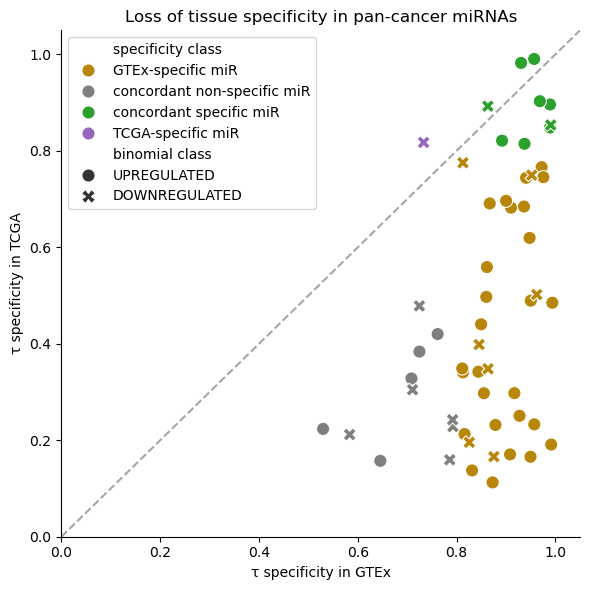

In [111]:
fig, ax = plt.subplots(figsize=(6,6))

palette = {
    'GTEx-specific miR': '#B8860B',
    'concordant specific miR': '#2ca02c',
    'concordant non-specific miR': '#7f7f7f',
    'TCGA-specific miR': '#9467bd'
}


sns.scatterplot(
    data=selected_mirs,
    x='τ GTEx',
    y='τ TCGA',
    hue='specificity class',
    style='binomial class',
    palette=palette,
    s=90,
    ax=ax
)

# diagonal
lims = [0, 1.05]

ax.plot(
    lims,
    lims,
    '--',
    color='gray',
    alpha=0.7
)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('τ specificity in GTEx')
ax.set_ylabel('τ specificity in TCGA')

ax.set_title('Loss of tissue specificity in pan-cancer miRNAs')
plt.savefig('/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/tau_tau.pdf', bbox_inches="tight")

sns.despine()
plt.tight_layout()
plt.show()

In [42]:
import pandas as pd
from scipy.stats import chi2_contingency

# исключаем singleton
df_stats = selected_mirs[
    selected_mirs['specificity class'] != 'TCGA-specific miR'
]

# contingency table
cont_table = pd.crosstab(
    df_stats['specificity class'],
    df_stats['binomial class']
)

print(cont_table)

binomial class               DOWNREGULATED  UPREGULATED
specificity class                                      
GTEx-specific miR                        7           25
concordant non-specific miR              6            4
concordant specific miR                  2            7


In [116]:
cols_to_save = ['mature_name', 'tcga_tau', 'tau_gtex', 'tcga_pref_type', 'pref_smts_highq', 'final_annotation', 'n_projects_up', 'n_projects_down',
'binom_p_two_sided', 'binom_p_up', 'binom_p_down', 'STN_class', 'median_log2fc', 'median_padj']

merged = merged[cols_to_save]

merged.rename(columns={'mature_name' :'miRNA', 'tcga_tau': 'τ TCGA', 'tau_gtex': 'τ GTEx', 
'tcga_pref_type': 'TCGA specificity', 'pref_smts_highq': 'GTEx specificity', 
'final_annotation': 'Specificity class', 'STN_class': 'Binomial class'}, inplace=True)

merged.head()

/var/folders/np/46xyw0ds0t7g3v5c2ywcpmpc0000gn/T/ipykernel_2293/3443963410.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged.rename(columns={'mature_name' :'miRNA', 'tcga_tau': 'τ TCGA', 'tau_gtex': 'τ GTEx',


,miRNA,τ TCGA,τ GTEx,TCGA specificity,GTEx specificity,Specificity class,n_projects_up,n_projects_down,binom_p_two_sided,binom_p_up,binom_p_down,Binomial class,median_log2fc,median_padj
0,hsa-let-7a-2-3p,0.357379,0.960525,-,Bladder,GTEx-specific miR,3,1,0.625000,0.312500,0.937500,NOT_SIGNIFICANT,-0.544267,9.617252e-04
1,hsa-let-7a-3p,0.231600,0.770218,-,-,concordant non-specific miR,1,0,1.000000,0.500000,1.000000,NOT_SIGNIFICANT,-0.022187,2.011985e-05
2,hsa-let-7b-5p,0.153265,0.526175,-,-,concordant non-specific miR,2,2,1.000000,0.687500,0.687500,NOT_SIGNIFICANT,-0.381554,8.303934e-07
3,hsa-let-7c-3p,0.343961,0.567580,-,-,concordant non-specific miR,4,6,0.753906,0.828125,0.376953,NOT_SIGNIFICANT,-0.454561,7.149929e-06
4,hsa-let-7d-5p,0.288760,0.687970,-,-,concordant non-specific miR,0,0,NaN,NaN,NaN,NOT_SIGNIFICANT,0.294442,3.498912e-04


In [162]:
x=merged[merged['Binomial class'] != 'NOT_SIGNIFICANT']
x['Specificity class'].value_counts()

Specificity class
GTEx-specific miR              34
concordant non-specific miR    11
concordant specific miR         9
TCGA-specific miR               1
Name: count, dtype: int64

In [164]:
x[x['Specificity class']=='GTEx-specific miR']['Binomial class'].value_counts()

Binomial class
UPREGULATED      27
DOWNREGULATED     7
Name: count, dtype: int64